<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Multi-Crop-Ranking/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score,
                             roc_curve, auc, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from scipy.stats import spearmanr

**1. LOAD DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DSGP/Crop_training_data_FULL_final.csv")

**2. EDA AND PREPROCESSING**

In [ ]:
#Encode target: Suitable=1, Unsuitable=0
df['target'] = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

In [ ]:
#Feature Selection
X_raw = df.drop(columns=['suitability_class', 'target', 'suitability', 'texture'])
y = df['target']

In [ ]:
#One-Hot Encoding for the 'crop' categorical variable
X = pd.get_dummies(X_raw, columns=['crop'], prefix='crop')
feature_names = X.columns.tolist()

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**3. HYPERPARAMETER TUNING**

In [ ]:
#Logistic Regression
param_lr = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                       param_lr, scoring='roc_auc', cv=5).fit(X_train_scaled, y_train)

In [ ]:
#Random Forest
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                       param_rf, scoring='roc_auc', cv=5).fit(X_train, y_train)

In [ ]:
#SVM
param_svm = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1], 'kernel': ['rbf']}
grid_svm = GridSearchCV(SVC(probability=True, class_weight='balanced'),
                        param_svm, scoring='roc_auc', cv=5).fit(X_train_scaled, y_train)

**4. MODEL EVALUATION & SELECTION**

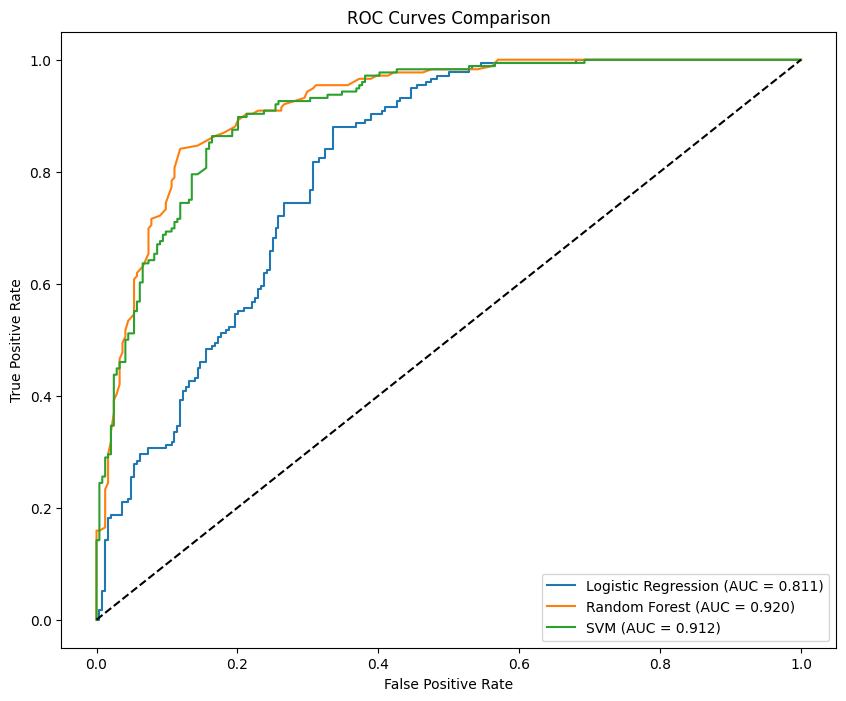


Final Selected Best Model: Random Forest


In [ ]:
models = {
    'Logistic Regression': (grid_lr.best_estimator_, X_test_scaled),
    'Random Forest': (grid_rf.best_estimator_, X_test),
    'SVM': (grid_svm.best_estimator_, X_test_scaled)
}

results_list = []
plt.figure(figsize=(10, 8))

for name, (model, data) in models.items():
    probs = model.predict_proba(data)[:, 1]
    auc_score = roc_auc_score(y_test, probs)
    results_list.append({'Model': name, 'ROC-AUC': auc_score})

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

results_df = pd.DataFrame(results_list).sort_values(by='ROC-AUC', ascending=False)
best_model_name = results_df.iloc[0]['Model']
best_model, best_X_test = models[best_model_name]

print(f"\nFinal Selected Best Model: {best_model_name}")

**5. VALIDATING THE RANKING**

In [ ]:
y_probs = best_model.predict_proba(best_X_test)[:, 1]


--- Ranking Accuracy (Precision@K) ---
Precision at Top 10%: 92.86%
Precision at Top 20%: 90.48%
Precision at Top 40%: 83.93%


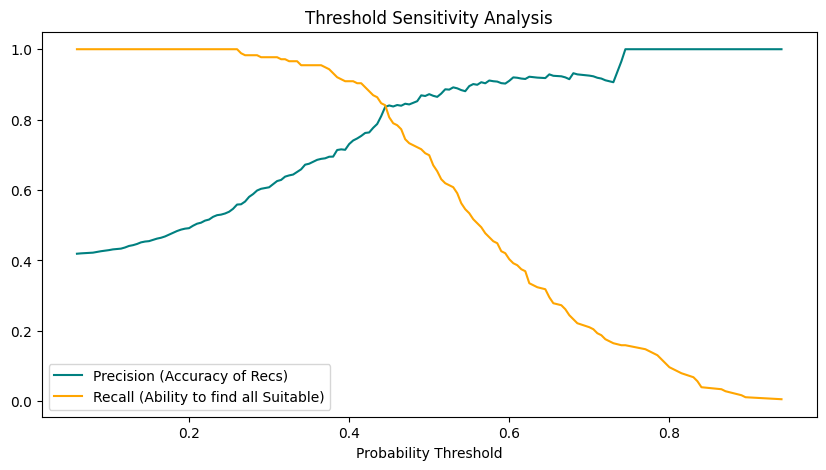

In [ ]:
def precision_at_k(y_true, y_probs, k_percent):
    temp = pd.DataFrame({'true': y_true, 'prob': y_probs}).sort_values('prob', ascending=False)
    n_k = int(len(temp) * k_percent)
    return temp.head(n_k)['true'].mean()

print("\n--- Ranking Accuracy (Precision@K) ---")
for k in [0.1, 0.2, 0.4]:
    print(f"Precision at Top {int(k*100)}%: {precision_at_k(y_test, y_probs, k):.2%}")

# Threshold Sensitivity Plot
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision (Accuracy of Recs)", color='teal')
plt.plot(thresholds, recalls[:-1], label="Recall (Ability to find all Suitable)", color='orange')
plt.title("Threshold Sensitivity Analysis")
plt.xlabel("Probability Threshold")
plt.legend()
plt.show()

**6. DYNAMIC RANKING ENGINE**

In [ ]:
def rank_crops_for_user(user_input, model, scaler, feature_names, original_df):
    all_crops = original_df['crop'].unique()
    query_list = []

    for crop in all_crops:
        row = user_input.copy()

        for col in feature_names:
            if col.startswith('crop_'):
                row[col] = 1 if col == f"crop_{crop}" else 0
        query_list.append(row)

    query_df = pd.DataFrame(query_list)[feature_names]

    if scaler and best_model_name != 'Random Forest':
        query_df = scaler.transform(query_df)

    scores = model.predict_proba(query_df)[:, 1]
    return pd.DataFrame({'Crop': all_crops, 'Score': scores}).sort_values('Score', ascending=False)

**- Example**

In [ ]:
user_input = {
    'temperature': 28.5, 'rainfall': 1100, 'sunshine_hours': 7.2,
    'ph': 6.2, 'organic_carbon': 1.2, 'cec': 15.0,
    'awc': 0.02, 'bulk_density': 1.3, 'rooting_depth_m': 0.8, 'texture_code': 4
}

final_rankings = rank_crops_for_user(user_input, best_model, scaler, feature_names, df)
print("\n--- Final Recommended Ranking for User Conditions ---")
print(final_rankings.head(5))


--- Final Recommended Ranking for User Conditions ---
             Crop  Score
15       Rambutan  0.890
9          Banana  0.875
16     Mangosteen  0.840
12         Papaya  0.835
13  Passion Fruit  0.815
